Realized vol proxy loaded, NaNs: 2346
df_ml shape: (97603, 23), NaN counts:
is_fomc_day       0
is_cpi_day        0
is_nfp_day        0
vix            1955
dtype: int64
Train: 78053 bars  (up to 2023-07-21)
Test : 19550 bars  (from 2023-07-21)


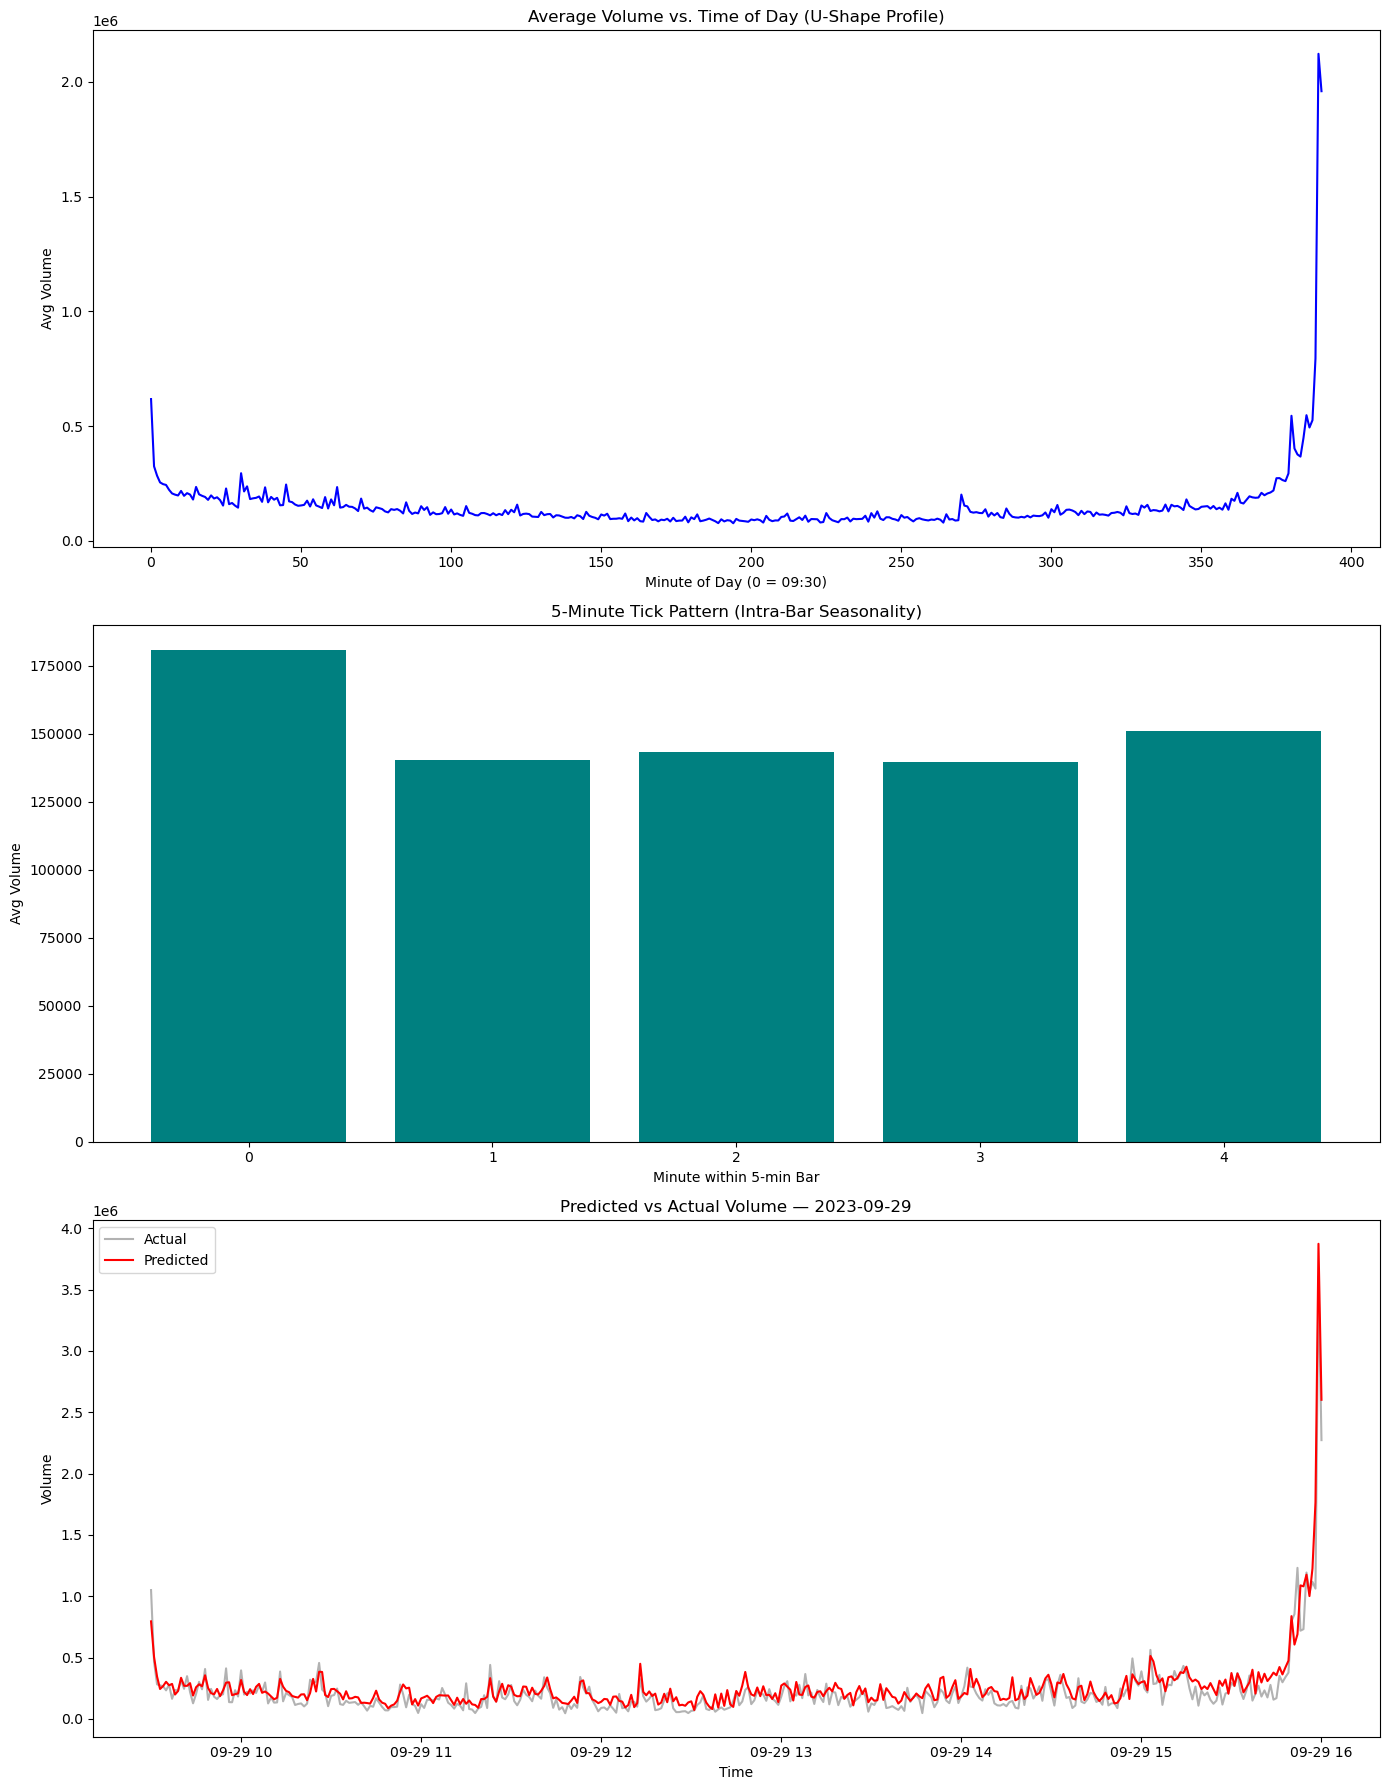

CORE REGRESSION METRICS
           MAE  Median AE     RMSE  MAPE (%)  SMAPE (%)      R²  Adj R²  MBE (bias)
Set                                                                                
Train  39299.9    26536.2  68230.8     59.53      28.07  0.8818  0.8818       120.2
Test   41435.6    27938.8  69373.3     36.50      30.27  0.8349  0.8347      9122.2

BASELINE COMPARISON  (Test Set)
                          MAE      RMSE  MAPE (%)      R²
Model                                                    
Hist-Bin-Avg (5-day)  58899.1   96918.1     52.86  0.6777
Lag-1 (prev bar)      58774.1  129146.4     43.64  0.4278
Train Mean            86871.6  171116.4     93.63 -0.0046
GBM Model             41435.6   69373.3     36.50  0.8349

  Skill Score vs Hist-Bin-Avg: 29.65%  (improvement)

ERROR DISTRIBUTION ANALYSIS  (Test Set)
            Abs Error
Percentile           
1               499.9
5              2544.6
25            12905.2
50            27938.8
75            52598.7
90        

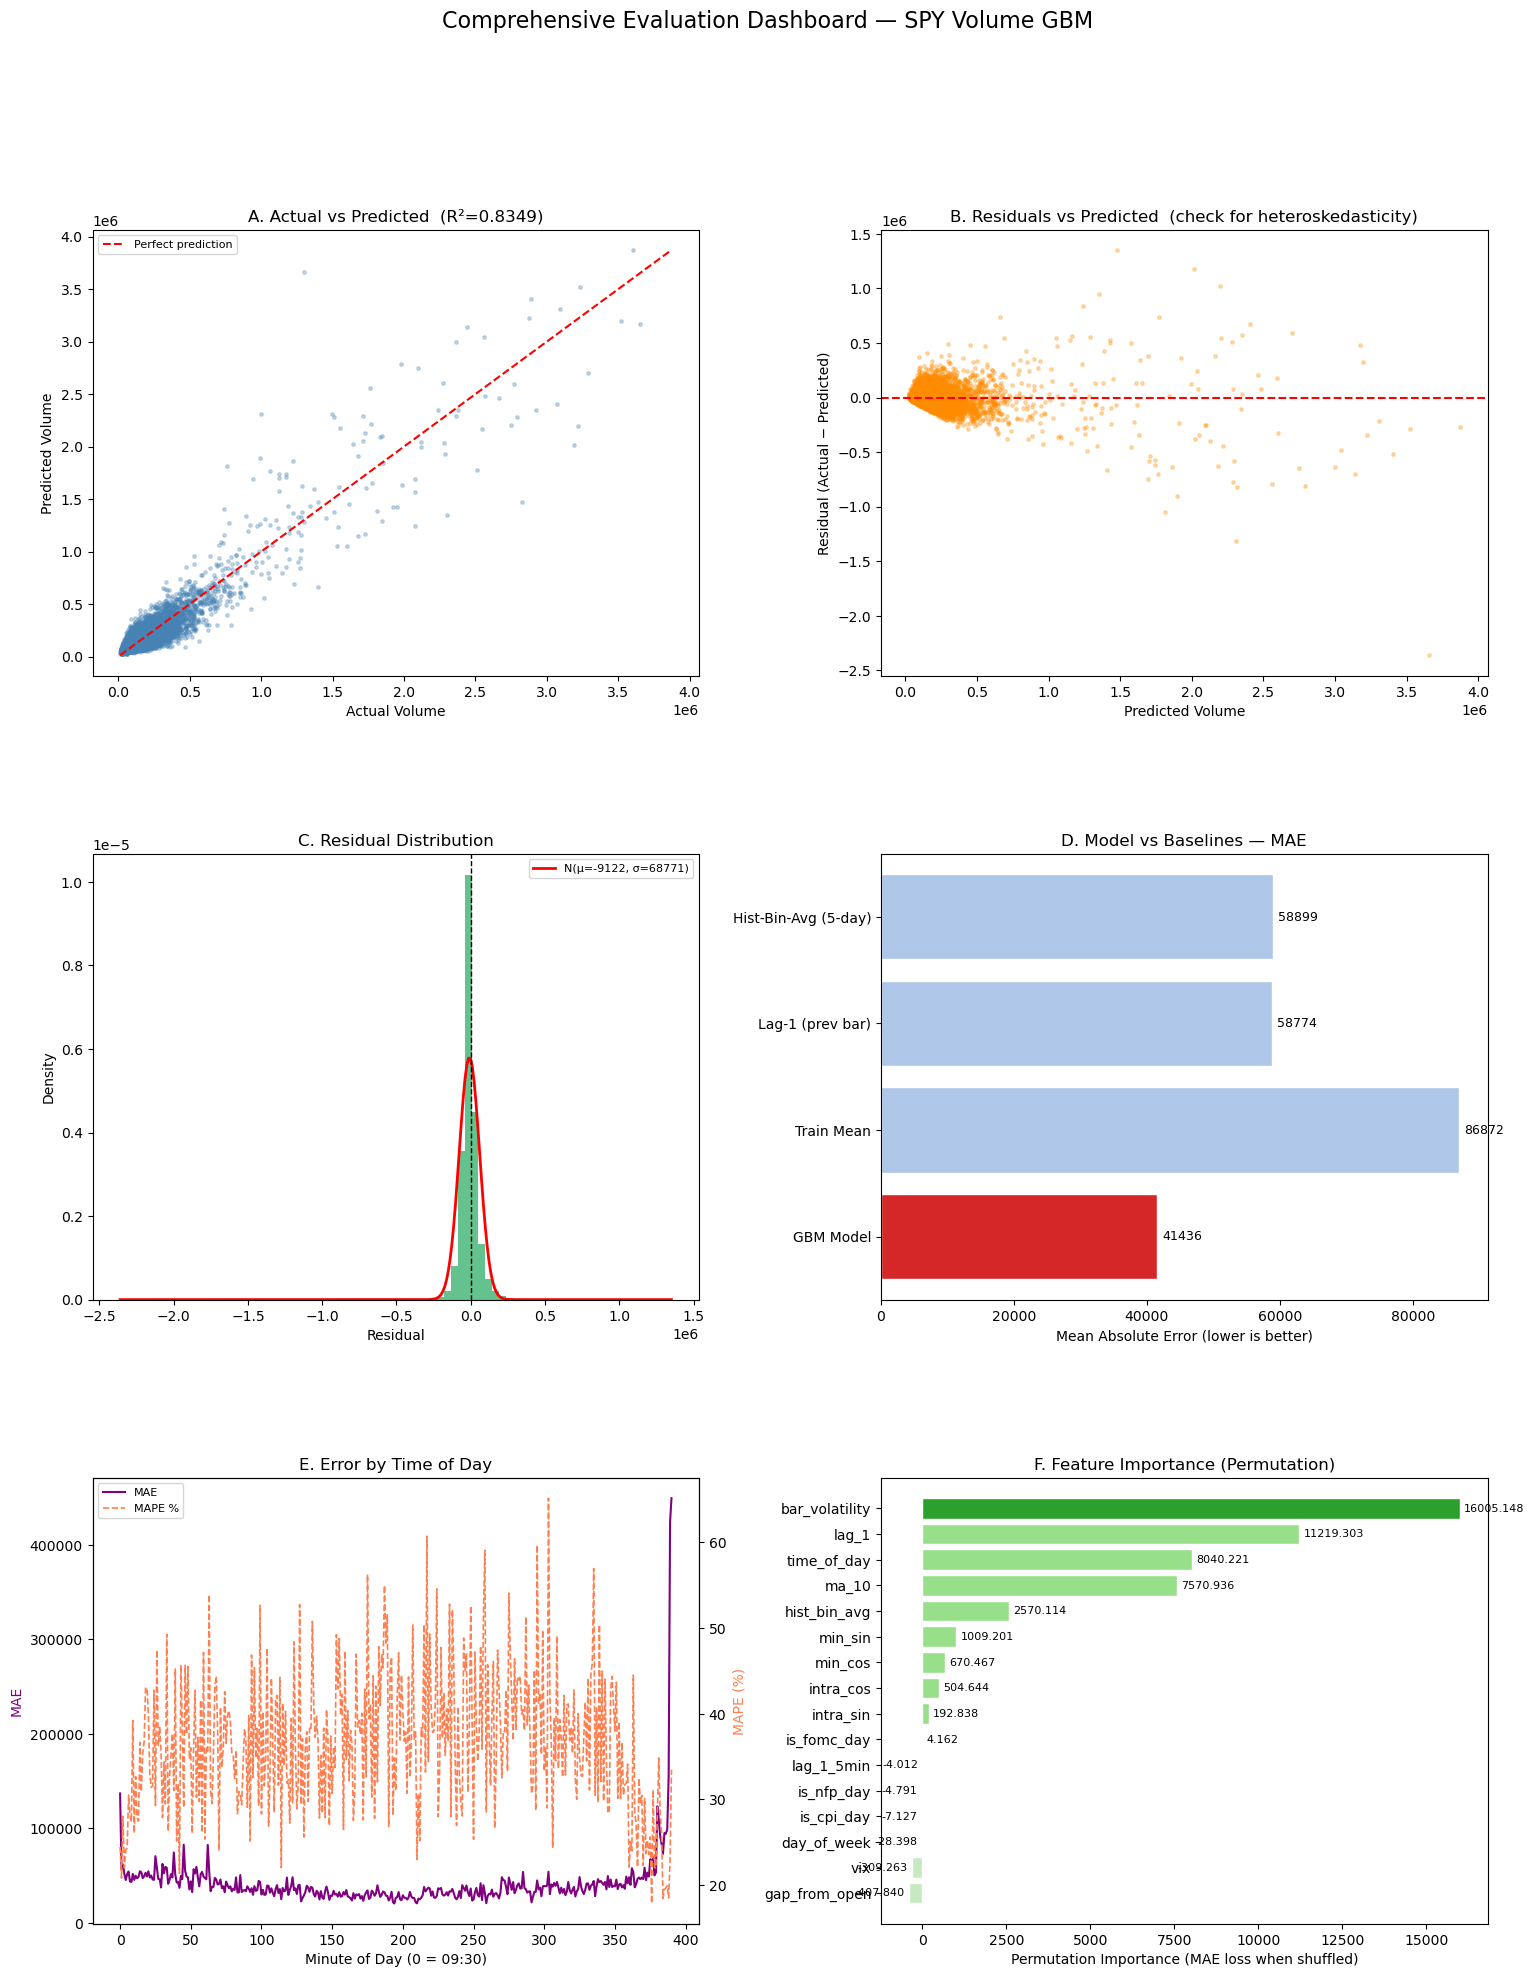


FINAL SCORECARD SUMMARY
  Metric                                Train         Test
  ------------------------------------------------------
  MAE                                 39299.9      41435.6
  RMSE                                68230.8      69373.3
  MAPE (%)                              59.53         36.5
  R²                                   0.8818       0.8349
  Adj R²                               0.8818       0.8347
  MBE (bias)                            120.2       9122.2

  Skill Score vs Best Baseline              —      29.65%
  Preds within ±10% (test)                  —       20.6%
  Preds within ±25% (test)                  —       47.8%
  Overfitting flag (R² gap)                 —           NO


In [1]:
# Data source: 1 min interval SPY data from FirstRateData from 2022 to 2023
# SPY Volume Prediction - GBM Model with Extended Features

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor

# 1. Data Prep
df = pd.read_csv('SPY_1min_firstratedata.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df_rth = df.set_index('timestamp').between_time('09:30', '16:00').copy()
df_rth['minute_of_day'] = (df_rth.index.hour * 60 + df_rth.index.minute) - 570
df_rth['intra_5min'] = df_rth['minute_of_day'] % 5

# 2. Cyclical Encoding
df_rth['min_sin']   = np.sin(2 * np.pi * df_rth['minute_of_day'] / 390)
df_rth['min_cos']   = np.cos(2 * np.pi * df_rth['minute_of_day'] / 390)
df_rth['intra_sin'] = np.sin(2 * np.pi * df_rth['intra_5min'] / 5)
df_rth['intra_cos'] = np.cos(2 * np.pi * df_rth['intra_5min'] / 5)

# 3. Lags & Moving Average
df_rth['lag_1'] = df_rth['volume'].shift(1)
df_rth['ma_10'] = df_rth['volume'].rolling(window=10).mean().shift(1)

# 4. Extended Features
df_rth['time_of_day'] = df_rth['minute_of_day']
df_rth['day_of_week'] = df_rth.index.dayofweek
df_rth['lag_1_5min']  = df_rth['volume'].shift(5)

df_rth = df_rth.sort_index()
df_rth['hist_bin_avg'] = (
    df_rth.groupby('minute_of_day')['volume']
          .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)

df_rth['bar_volatility'] = df_rth['high'] - df_rth['low']

daily_open  = df_rth.groupby(df_rth.index.date)['open'].first().rename('day_open')
daily_close = df_rth.groupby(df_rth.index.date)['close'].last().rename('prev_close')
daily_close.index = pd.to_datetime(daily_close.index)
daily_open.index  = pd.to_datetime(daily_open.index)
gap_df = pd.DataFrame({'day_open': daily_open, 'prev_close': daily_close.shift(1)})
gap_df['gap_from_open'] = (gap_df['day_open'] - gap_df['prev_close']) / gap_df['prev_close'] * 100
df_rth['gap_from_open'] = df_rth.index.normalize().map(gap_df['gap_from_open'])

# 5. Macro / News Features
fomc_dates = pd.to_datetime([
    '2022-01-26', '2022-03-16', '2022-05-04', '2022-06-15',
    '2022-07-27', '2022-09-21', '2022-11-02', '2022-12-14',
    '2023-02-01', '2023-03-22', '2023-05-03', '2023-06-14',
    '2023-07-26', '2023-09-20', '2023-11-01', '2023-12-13',
])

# Hardcoded CPI release dates (BLS publishes ~2nd week of following month)
cpi_dates = pd.to_datetime([
    '2022-01-12', '2022-02-10', '2022-03-10', '2022-04-12',
    '2022-05-11', '2022-06-10', '2022-07-13', '2022-08-10',
    '2022-09-13', '2022-10-13', '2022-11-10', '2022-12-13',
    '2023-01-12', '2023-02-14', '2023-03-14', '2023-04-12',
    '2023-05-10', '2023-06-13', '2023-07-12', '2023-08-10',
    '2023-09-13', '2023-10-12', '2023-11-14', '2023-12-12',
])

# Hardcoded NFP release dates (BLS publishes first Friday of following month)
nfp_dates = pd.to_datetime([
    '2022-01-07', '2022-02-04', '2022-03-04', '2022-04-01',
    '2022-05-06', '2022-06-03', '2022-07-08', '2022-08-05',
    '2022-09-02', '2022-10-07', '2022-11-04', '2022-12-02',
    '2023-01-06', '2023-02-03', '2023-03-10', '2023-04-07',
    '2023-05-05', '2023-06-02', '2023-07-07', '2023-08-04',
    '2023-09-01', '2023-10-06', '2023-11-03', '2023-12-08',
])

trading_dates = df_rth.index.normalize()
df_rth['is_fomc_day'] = trading_dates.isin(fomc_dates).astype(int)
df_rth['is_cpi_day']  = trading_dates.isin(cpi_dates).astype(int)
df_rth['is_nfp_day']  = trading_dates.isin(nfp_dates).astype(int)

# VIX proxy: 20-day realized volatility from SPY returns
# (well-established academic alternative to VIX, no external data needed)
daily_ret = (df_rth.groupby(df_rth.index.date)['close']
                   .last()
                   .pct_change())
daily_ret.index = pd.to_datetime(daily_ret.index)
realized_vol = daily_ret.rolling(20, min_periods=5).std() * np.sqrt(252) * 100
realized_vol_lagged = realized_vol.shift(1)
df_rth['vix'] = trading_dates.map(realized_vol_lagged)
print(f"Realized vol proxy loaded, NaNs: {df_rth['vix'].isna().sum()}")



# dropna AFTER all features are built
df_ml = df_rth.dropna(subset=[c for c in df_rth.columns if c != 'vix'])
print(f"df_ml shape: {df_ml.shape}, NaN counts:\n{df_ml[['is_fomc_day','is_cpi_day','is_nfp_day','vix']].isna().sum()}")

# 6. Train/Test Split
features = [
    'min_sin', 'min_cos', 'intra_sin', 'intra_cos',
    'lag_1', 'ma_10',
    'time_of_day', 'day_of_week', 'lag_1_5min',
    'hist_bin_avg', 'bar_volatility', 'gap_from_open',
    'is_fomc_day', 'is_cpi_day', 'is_nfp_day',
    'vix',
]

unique_days = sorted(df_ml.index.normalize().unique())
cutoff_day  = unique_days[int(len(unique_days) * 0.8)]
train_mask  = df_ml.index.normalize() < cutoff_day
test_mask   = df_ml.index.normalize() >= cutoff_day

X, y             = df_ml[features], df_ml['volume']
X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"Train: {train_mask.sum()} bars  (up to {cutoff_day.date()})")
print(f"Test : {test_mask.sum()} bars  (from {cutoff_day.date()})")

# HistGradientBoosting handles NaN natively, so missing VIX bars are fine
model  = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.1).fit(X_train, y_train)
y_pred = model.predict(X_test)




# Visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# Subplot 1: Avg Volume vs Time (U-Shape)
avg_vol_tod = df_rth.groupby('minute_of_day')['volume'].mean()
axes[0].plot(avg_vol_tod.index, avg_vol_tod.values, color='blue')
axes[0].set_title('Average Volume vs. Time of Day (U-Shape Profile)')
axes[0].set_xlabel('Minute of Day (0 = 09:30)')
axes[0].set_ylabel('Avg Volume')

# Subplot 2: 5-Min Tick Pattern
avg_vol_5min = df_rth.groupby('intra_5min')['volume'].mean()
axes[1].bar(avg_vol_5min.index, avg_vol_5min.values, color='teal')
axes[1].set_title('5-Minute Tick Pattern (Intra-Bar Seasonality)')
axes[1].set_xlabel('Minute within 5-min Bar')
axes[1].set_ylabel('Avg Volume')

# Subplot 3: Predicted vs Actual (last trading day in test set)
last_day = df_ml.index[test_mask].normalize().max()
sample_mask = df_ml.index[test_mask].normalize() == last_day
axes[2].plot(df_ml.index[test_mask][sample_mask],
             y_test.values[sample_mask],
             color='gray', alpha=0.6, label='Actual')
axes[2].plot(df_ml.index[test_mask][sample_mask],
             y_pred[sample_mask],
             color='red', label='Predicted')
axes[2].set_title(f'Predicted vs Actual Volume — {last_day.date()}')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Volume')
axes[2].legend()

plt.tight_layout()
plt.show()




"""
COMPREHENSIVE EVALUATION METRICS — SPY Volume GBM Model
========================================================
Drop this cell directly after your existing model cell in ML_Project_v5.ipynb.
Assumes: model, X, y, split, features, df_ml are already defined.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
    median_absolute_error,
)
from scipy import stats
from sklearn.inspection import permutation_importance

# ─────────────────────────────────────────────
# 0. Setup — split predictions and actuals
# ─────────────────────────────────────────────
# y_train, y_test, X_train, X_test are defined in the model cell
# (day-based split — no rows from the same day span both sets)
y_pred_train = model.predict(X_train)
y_pred_test  = y_pred   # already computed in your previous cell

residuals_test  = y_test.values - y_pred_test
residuals_train = y_train.values - y_pred_train

# ─────────────────────────────────────────────
# 1. Core Regression Metrics
# ─────────────────────────────────────────────
def regression_metrics(y_true, y_pred, label=""):
    mae   = mean_absolute_error(y_true, y_pred)
    mdae  = median_absolute_error(y_true, y_pred)
    mape  = mean_absolute_percentage_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)
    # Adjusted R² (corrects for number of features)
    n, p  = len(y_true), len(features)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    # Mean Bias Error — positive = model over-predicts
    mbe   = np.mean(y_pred - y_true)
    # Symmetric MAPE — less sensitive to near-zero values
    smape = np.mean(2 * np.abs(y_pred - y_true) /
                    (np.abs(y_true) + np.abs(y_pred) + 1e-9)) * 100

    return {
        "Set"          : label,
        "MAE"          : round(mae, 1),
        "Median AE"    : round(mdae, 1),
        "RMSE"         : round(rmse, 1),
        "MAPE (%)"     : round(mape * 100, 2),
        "SMAPE (%)"    : round(smape, 2),
        "R²"           : round(r2, 4),
        "Adj R²"       : round(adj_r2, 4),
        "MBE (bias)"   : round(mbe, 1),
    }

train_metrics = regression_metrics(y_train, y_pred_train, "Train")
test_metrics  = regression_metrics(y_test,  y_pred_test,  "Test")

metrics_df = pd.DataFrame([train_metrics, test_metrics]).set_index("Set")
print("=" * 70)
print("CORE REGRESSION METRICS")
print("=" * 70)
print(metrics_df.to_string())

# ─────────────────────────────────────────────
# 2. Naive Baseline Comparison
# ─────────────────────────────────────────────
# Baseline 1: historical bin average (already a feature)
baseline_hist = df_ml.loc[test_mask, "hist_bin_avg"]
# Baseline 2: lag_1 (just copy the previous bar's volume)
baseline_lag1 = df_ml.loc[test_mask, "lag_1"]
# Baseline 3: overall test-set mean
baseline_mean = pd.Series(np.full(len(y_test), y_train.mean()), index=y_test.index)

baselines = {
    "Hist-Bin-Avg (5-day)" : baseline_hist,
    "Lag-1 (prev bar)"     : baseline_lag1,
    "Train Mean"           : baseline_mean,
    "GBM Model"            : pd.Series(y_pred_test, index=y_test.index),
}

print("\n" + "=" * 70)
print("BASELINE COMPARISON  (Test Set)")
print("=" * 70)
rows = []
for name, pred in baselines.items():
    valid = y_test.index.intersection(pred.index)
    rows.append({
        "Model"    : name,
        "MAE"      : round(mean_absolute_error(y_test.loc[valid], pred.loc[valid]), 1),
        "RMSE"     : round(np.sqrt(mean_squared_error(y_test.loc[valid], pred.loc[valid])), 1),
        "MAPE (%)" : round(mean_absolute_percentage_error(y_test.loc[valid], pred.loc[valid]) * 100, 2),
        "R²"       : round(r2_score(y_test.loc[valid], pred.loc[valid]), 4),
    })

baseline_df = pd.DataFrame(rows).set_index("Model")
print(baseline_df.to_string())

# Skill score vs. best naive baseline (hist_bin_avg)
best_baseline_mae = baseline_df.loc["Hist-Bin-Avg (5-day)", "MAE"]
model_mae         = baseline_df.loc["GBM Model", "MAE"]
skill_score       = 1 - (model_mae / best_baseline_mae)
print(f"\n  Skill Score vs Hist-Bin-Avg: {skill_score:.2%}  "
      f"({'improvement' if skill_score > 0 else 'worse than baseline'})")

# ─────────────────────────────────────────────
# 3. Error Distribution Analysis
# ─────────────────────────────────────────────
pct_errors = residuals_test / (y_test.values + 1e-9) * 100   # % error per bar

print("\n" + "=" * 70)
print("ERROR DISTRIBUTION ANALYSIS  (Test Set)")
print("=" * 70)
percentiles = [1, 5, 25, 50, 75, 90, 95, 99]
pct_vals = np.percentile(np.abs(residuals_test), percentiles)
err_dist = pd.DataFrame({"Percentile": percentiles,
                         "Abs Error":  np.round(pct_vals, 1)}).set_index("Percentile")
print(err_dist.to_string())

within_10 = np.mean(np.abs(pct_errors) <= 10) * 100
within_25 = np.mean(np.abs(pct_errors) <= 25) * 100
within_50 = np.mean(np.abs(pct_errors) <= 50) * 100
print(f"\n  Predictions within ±10%: {within_10:.1f}% of bars")
print(f"  Predictions within ±25%: {within_25:.1f}% of bars")
print(f"  Predictions within ±50%: {within_50:.1f}% of bars")

# ─────────────────────────────────────────────
# ─────────────────────────────────────────────
# 4. Feature Importance  (Permutation — works with HistGBM)
# ─────────────────────────────────────────────
# HistGradientBoostingRegressor has no .feature_importances_;
# permutation_importance measures how much each feature hurts
# performance when its values are randomly shuffled.
perm = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error",
)
importance_df = (
    pd.DataFrame({
        "Importance (mean MAE loss)" : perm.importances_mean,
        "Std"                        : perm.importances_std,
    }, index=features)
    .sort_values("Importance (mean MAE loss)", ascending=False)
)

print("\n" + "=" * 70)
print("FEATURE IMPORTANCE  (Permutation Importance, Test Set)")
print("Higher = model relies on this feature more")
print("=" * 70)
print(importance_df.round(4).to_string())

# 5. Time-of-Day Error Profile
# ─────────────────────────────────────────────
tod_df = pd.DataFrame({
    "minute_of_day" : df_ml.loc[test_mask, "minute_of_day"].values,
    "abs_error"     : np.abs(residuals_test),
    "pct_error"     : np.abs(pct_errors),
})
tod_summary = (
    tod_df.groupby("minute_of_day")
          .agg(mae=("abs_error", "mean"), mape=("pct_error", "mean"))
          .round(2)
)
# Worst 10 minutes of the day
print("\n" + "=" * 70)
print("TIME-OF-DAY ERROR  (Top 10 Worst Minutes)")
print("=" * 70)
print(tod_summary.nlargest(10, "mape").to_string())

# ─────────────────────────────────────────────
# 6. Train vs Test Overfitting Check
# ─────────────────────────────────────────────
overfit_ratio = test_metrics["RMSE"] / train_metrics["RMSE"]
r2_gap        = train_metrics["R²"] - test_metrics["R²"]
print("\n" + "=" * 70)
print("OVERFITTING DIAGNOSTICS")
print("=" * 70)
print(f"  Train RMSE : {train_metrics['RMSE']:>10,.1f}")
print(f"  Test  RMSE : {test_metrics['RMSE']:>10,.1f}")
print(f"  RMSE Ratio (Test/Train) : {overfit_ratio:.3f}  "
      f"({'⚠ possible overfit' if overfit_ratio > 1.3 else '✓ reasonable'})")
print(f"  R² Gap (Train - Test)   : {r2_gap:.4f}  "
      f"({'⚠ possible overfit' if r2_gap > 0.1 else '✓ reasonable'})")

# ─────────────────────────────────────────────
# 7. Visualisations — 6-panel dashboard
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 22))
fig.suptitle("Comprehensive Evaluation Dashboard — SPY Volume GBM", fontsize=16, y=0.98)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.40, wspace=0.30)

# ── Panel A: Actual vs Predicted scatter ──────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
ax0.scatter(y_test, y_pred_test, alpha=0.3, s=6, color="steelblue", rasterized=True)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax0.plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
ax0.set_xlabel("Actual Volume")
ax0.set_ylabel("Predicted Volume")
ax0.set_title(f"A. Actual vs Predicted  (R²={test_metrics['R²']})")
ax0.legend(fontsize=8)

# ── Panel B: Residuals vs Predicted ───────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
ax1.scatter(y_pred_test, residuals_test, alpha=0.3, s=6, color="darkorange", rasterized=True)
ax1.axhline(0, color="red", lw=1.5, ls="--")
ax1.set_xlabel("Predicted Volume")
ax1.set_ylabel("Residual (Actual − Predicted)")
ax1.set_title("B. Residuals vs Predicted  (check for heteroskedasticity)")

# ── Panel C: Residual Distribution ────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(residuals_test, bins=80, color="mediumseagreen", edgecolor="none", alpha=0.8, density=True)
mu, sigma = residuals_test.mean(), residuals_test.std()
x_norm = np.linspace(residuals_test.min(), residuals_test.max(), 300)
ax2.plot(x_norm, stats.norm.pdf(x_norm, mu, sigma), "r-", lw=2, label=f"N(μ={mu:.0f}, σ={sigma:.0f})")
ax2.axvline(0, color="black", lw=1, ls="--")
ax2.set_xlabel("Residual")
ax2.set_ylabel("Density")
ax2.set_title("C. Residual Distribution")
ax2.legend(fontsize=8)

# ── Panel D: Baseline Comparison Bar Chart ────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
colors = ["#d62728" if n == "GBM Model" else "#aec7e8" for n in baseline_df.index]
bars = ax3.barh(baseline_df.index, baseline_df["MAE"], color=colors, edgecolor="white")
ax3.bar_label(bars, fmt="%.0f", padding=4, fontsize=9)
ax3.set_xlabel("Mean Absolute Error (lower is better)")
ax3.set_title("D. Model vs Baselines — MAE")
ax3.invert_yaxis()

# ── Panel E: Time-of-Day Error Profile ────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(tod_summary.index, tod_summary["mae"], color="purple", lw=1.5, label="MAE")
ax4_twin = ax4.twinx()
ax4_twin.plot(tod_summary.index, tod_summary["mape"], color="coral", lw=1.2, ls="--", label="MAPE %")
ax4.set_xlabel("Minute of Day (0 = 09:30)")
ax4.set_ylabel("MAE", color="purple")
ax4_twin.set_ylabel("MAPE (%)", color="coral")
ax4.set_title("E. Error by Time of Day")
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

# ── Panel F: Feature Importance ───────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
colors_fi = ["#2ca02c" if i == 0 else "#98df8a" if importance_df["Importance (mean MAE loss)"].values[i] > 0.1 else "#c7e9c0" for i in range(len(importance_df))]
bars_fi = ax5.barh(importance_df.index[::-1],
                   importance_df["Importance (mean MAE loss)"].values[::-1],
                   color=colors_fi[::-1], edgecolor="white")
ax5.bar_label(bars_fi, fmt="%.3f", padding=3, fontsize=8)
ax5.set_xlabel("Permutation Importance (MAE loss when shuffled)")
ax5.set_title("F. Feature Importance (Permutation)")

plt.show()

# ─────────────────────────────────────────────
# 8. Final Scorecard Summary
# ─────────────────────────────────────────────
print("\n" + "=" * 70)
print("FINAL SCORECARD SUMMARY")
print("=" * 70)
print(f"  {'Metric':<30} {'Train':>12} {'Test':>12}")
print("  " + "-" * 54)
for col in ["MAE", "RMSE", "MAPE (%)", "R²", "Adj R²", "MBE (bias)"]:
    print(f"  {col:<30} {train_metrics[col]:>12} {test_metrics[col]:>12}")
print(f"\n  {'Skill Score vs Best Baseline':<30} {'—':>12} {skill_score:>11.2%}")
print(f"  {'Preds within ±10% (test)':<30} {'—':>12} {within_10:>10.1f}%")
print(f"  {'Preds within ±25% (test)':<30} {'—':>12} {within_25:>10.1f}%")
print(f"  {'Overfitting flag (R² gap)':<30} {'—':>12} {'YES' if r2_gap > 0.1 else 'NO':>12}")
print("=" * 70)
